# **Interpretation of a Neural Network for Regulatory Compliance in Banking**


**Banca Virtuosa**, a leading institution in the financial sector, has identified the need to improve the transparency and interpretability of the artificial intelligence models used in its systems. To achieve this goal, Banca Virtuosa has launched a project aimed at implementing Explainable AI (XAI) techniques, in compliance with current regulations on banking transparency.

Currently, Banca Virtuosa uses pre-trained classification models to analyze and classify critical financial data. However, the lack of transparency in the decisions made by these models may undermine customer trust and limit the bank’s ability to improve its systems in a targeted way. Identifying and correcting classification errors is crucial to ensuring accuracy and reliability in the services offered.

<br>

##**Benefits of the Solution**

**1. Transparency in Model Decisions**

By implementing XAI techniques such as Grad-CAM, LIME, SHAP, Integrated Gradients, and Occlusion Maps, Banca Virtuosa will be able to generate saliency maps that visually show which elements influence the model’s decisions. This increase in transparency will improve the trust of customers and stakeholders, demonstrating the reliability and explainability of the classification system.

**2. Continuous Performance Improvement**

By analyzing saliency maps, Banca Virtuosa will be able to precisely identify the areas where the model makes mistakes, both in correct and incorrect classifications. This detailed analysis will enable targeted improvements to the model, optimizing its performance and reducing the risk of misinterpreting data.

**3. Regulatory Compliance**

The project will ensure that the decisions made by AI models are explainable and aligned with current regulatory requirements. Transparency in AI decisions is essential for regulatory compliance and corporate governance, especially in highly regulated sectors such as finance.

**4. Promotion of Innovation**

The adoption of advanced XAI techniques within Banca Virtuosa will promote innovation in artificial intelligence. This will strengthen the bank’s position as a pioneer in adopting advanced technologies, enabling it to offer customers increasingly sophisticated and reliable solutions.

<br>

##**Project Details**

**1. Phase 1: Use of a Pre-trained Classification Model**

- Model: Use a pre-trained model, such as DenseNet, from the torchvision library.

- Dataset: Apply the model to an image dataset, such as MNIST, to explore its classification decisions.

**2. Phase 2: Generation of Saliency Maps**

- XAI Techniques: Implement techniques such as Grad-CAM, LIME, SHAP, Integrated Gradients, and Occlusion Maps to generate saliency maps of the model.

**3. Phase 3: Final Report**
- Dataset Description: detail the origin, structure, and characteristics of the dataset used.

- Saliency Map Analysis: compare saliency maps for correctly classified and misclassified classes in order to identify and understand model errors.

- Explainable System (Optional): describe a fully explainable system that could perform the same classification task, providing additional insights into the model’s decision-making process.

<br>

##**Project Objectives**

**1. Model Understanding**
Use XAI techniques to gain a deep understanding of the internal functioning of the pre-trained model.

**2. Decision Visualization**
Clearly and interpretably visualize which elements influence the model’s decisions through saliency maps.

**3. Error Identification**
Analyze saliency maps to identify and understand model errors, distinguishing between correct and incorrect classifications.

**4. Creation of Explainable Systems**
If possible, develop or describe a fully explainable system capable of performing the same classification task, providing further insight into the model’s decisions.

<br>

##**Project Motivation**

Explainable AI techniques are essential for Banca Virtuosa to improve transparency, optimize model performance, and ensure regulatory compliance. Through this project, the bank aims to strengthen customer trust, improve operational efficiency, and promote innovation in the field of artificial intelligence.

# Setup

In [1]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
import sys
import os

sys.path.append(os.path.abspath("src"))

# Installation and Import

In [ ]:
# Install project dependencies
!pip install -r requirements.txt

In [1]:
# Core
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

# XAI
from captum.attr import IntegratedGradients, Occlusion
import lime
from lime import lime_image
import shap

import sklearn

# Image processing
import cv2

# Utils
from PIL import Image

print("Environment ready")
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)

Environment ready
Torch: 2.10.0+cpu
Numpy: 1.26.4


In [ ]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Load dataset

In [5]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# download dataset from Kaggle API
!kaggle datasets download -d matteocarnebella/cedar-signatures

Dataset URL: https://www.kaggle.com/datasets/matteocarnebella/cedar-signatures
License(s): unknown




  0%|          | 0.00/241M [00:00<?, ?B/s]
  0%|          | 1.00M/241M [00:00<02:01, 2.07MB/s]
  1%|          | 3.00M/241M [00:00<00:43, 5.80MB/s]
  2%|▏         | 6.00M/241M [00:00<00:22, 10.8MB/s]
  4%|▎         | 9.00M/241M [00:00<00:17, 14.1MB/s]
  5%|▍         | 12.0M/241M [00:01<00:13, 17.9MB/s]
  7%|▋         | 16.0M/241M [00:01<00:11, 21.0MB/s]
  8%|▊         | 19.0M/241M [00:01<00:10, 22.6MB/s]
  9%|▉         | 22.0M/241M [00:01<00:09, 24.1MB/s]
 11%|█         | 26.0M/241M [00:01<00:08, 26.6MB/s]
 12%|█▏        | 29.0M/241M [00:01<00:08, 27.4MB/s]
 13%|█▎        | 32.0M/241M [00:01<00:07, 28.1MB/s]
 15%|█▍        | 35.0M/241M [00:01<00:08, 24.7MB/s]
 16%|█▌        | 38.0M/241M [00:02<00:09, 22.9MB/s]
 17%|█▋        | 41.0M/241M [00:02<00:08, 23.6MB/s]
 18%|█▊        | 44.0M/241M [00:02<00:08, 23.2MB/s]
 20%|█▉        | 48.0M/241M [00:02<00:07, 26.1MB/s]
 21%|██        | 51.0M/241M [00:02<00:07, 27.4MB/s]
 23%|██▎       | 56.0M/241M [00:02<00:06, 30.6MB/s]
 25%|██▍       | 60.

In [7]:
# unzip dataset
!unzip cedar-signatures.zip -d data

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
import zipfile

zip_path = "cedar-signatures.zip"
extract_to = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted")

Dataset extracted


In [14]:
from pathlib import Path

data_path = Path("data/signatures/signatures_1")

files = sorted(list(data_path.glob("*.png")))

print("Total images:", len(files))
print("First files:", files[:5])

Total images: 48
First files: [WindowsPath('data/signatures/signatures_1/forgeries_1_1.png'), WindowsPath('data/signatures/signatures_1/forgeries_1_10.png'), WindowsPath('data/signatures/signatures_1/forgeries_1_11.png'), WindowsPath('data/signatures/signatures_1/forgeries_1_12.png'), WindowsPath('data/signatures/signatures_1/forgeries_1_13.png')]


In [15]:
genuine = [f for f in files if "original" in f.name.lower()]
forged = [f for f in files if "forg" in f.name.lower()]

print("Genuine:", len(genuine))
print("Forged:", len(forged))

Genuine: 24
Forged: 24


In [3]:
# load writers
from pathlib import Path

root = Path("data/signatures")

writers = list(root.glob("signatures_*"))

print("Number of Writers:", len(writers))

Number of Writers: 55


(-0.5, 587.5, 437.5, -0.5)

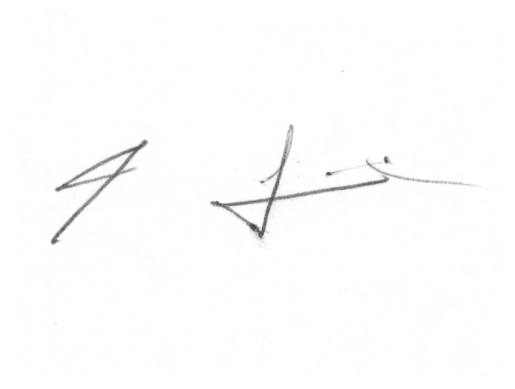

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

# img = Image.open(files[0])

img = Image.open(data_path / "forgeries_1_1.png")

plt.imshow(img, cmap="gray")
plt.axis("off")

(-0.5, 569.5, 371.5, -0.5)

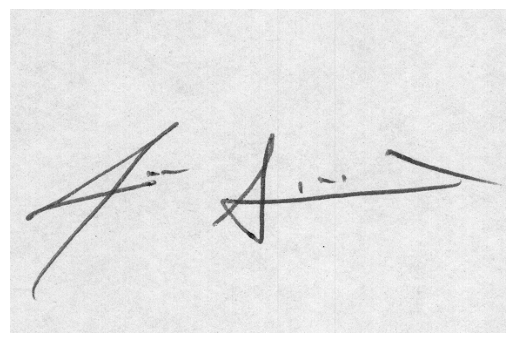

In [26]:
img = Image.open(data_path / "original_1_24.png")
img = Image.open(files[-1])

plt.imshow(img, cmap="gray")
plt.axis("off")

In [4]:
writers

[WindowsPath('data/signatures/signatures_1'),
 WindowsPath('data/signatures/signatures_10'),
 WindowsPath('data/signatures/signatures_11'),
 WindowsPath('data/signatures/signatures_12'),
 WindowsPath('data/signatures/signatures_13'),
 WindowsPath('data/signatures/signatures_14'),
 WindowsPath('data/signatures/signatures_15'),
 WindowsPath('data/signatures/signatures_16'),
 WindowsPath('data/signatures/signatures_17'),
 WindowsPath('data/signatures/signatures_18'),
 WindowsPath('data/signatures/signatures_19'),
 WindowsPath('data/signatures/signatures_2'),
 WindowsPath('data/signatures/signatures_20'),
 WindowsPath('data/signatures/signatures_21'),
 WindowsPath('data/signatures/signatures_22'),
 WindowsPath('data/signatures/signatures_23'),
 WindowsPath('data/signatures/signatures_24'),
 WindowsPath('data/signatures/signatures_25'),
 WindowsPath('data/signatures/signatures_26'),
 WindowsPath('data/signatures/signatures_27'),
 WindowsPath('data/signatures/signatures_28'),
 WindowsPath('d

In [12]:
# split writers (subject-level split)
import random

random.seed(42)
random.shuffle(writers)

n = len(writers)

train_writers = writers[:int(0.7*n)]
val_writers = writers[int(0.7*n):int(0.85*n)]
test_writers = writers[int(0.85*n):]

print("Train writers:", len(train_writers))
print("Val writers:", len(val_writers))
print("Test writers:", len(test_writers))

Train writers: 38
Val writers: 8
Test writers: 9


In [13]:
# Create dataset folders

base = Path("data")

for split in ["train", "val", "test"]:
    for cls in ["genuine", "forged"]:
        (base / split / cls).mkdir(parents=True, exist_ok=True)

print("Folders created")

Folders created


In [14]:
# copy images into splits

import shutil

def copy_images(writer_list, split):

    for writer in writer_list:

        for img in writer.glob("*.png"):

            name = img.name.lower()

            if "original" in name:
                dst = base / split / "genuine" / img.name

            elif "forgeries" in name:
                dst = base / split / "forged" / img.name

            shutil.copy(img, dst)


copy_images(train_writers, "train")
copy_images(val_writers, "val")
copy_images(test_writers, "test")

print("Dataset split complete")

Dataset split complete


In [16]:
# verify dataset statistics
def count_images(path):
    return len(list(path.glob("*.png")))

for split in ["train", "val", "test"]:

    g = count_images(base / split / "genuine")
    f = count_images(base / split / "forged")

    print(split, "genuine:", g, "forged:", f, "total:", g+f)

train genuine: 912 forged: 912 total: 1824
val genuine: 192 forged: 192 total: 384
test genuine: 216 forged: 216 total: 432


# Pre-Trained Classification Model

In [18]:
import torchvision.transforms as transforms